In [1]:
from pathlib import Path
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache
from abc_atlas_access.abc_atlas_cache.anndata_utils import get_gene_data
import pandas as pd
import numpy as np
import anndata
import matplotlib.pyplot as plt


### **1. Using the Cache**

In [2]:
download_base = Path('../../data/abc_atlas')
abc_cache = AbcProjectCache.from_cache_dir(download_base)

abc_cache.current_manifest

'releases/20251031/manifest.json'

### **2. Dataset Assembly**

In [3]:
abc_cache.list_metadata_files('Zeng-Aging-Mouse-10Xv3')

['cell_annotation_colors',
 'cell_cluster_annotations',
 'cell_metadata',
 'cluster',
 'donor',
 'example_genes_all_cells_expression',
 'library',
 'value_sets']

In [4]:
abc_cache.list_metadata_files('Zeng-Aging-Mouse-WMB-taxonomy')

['aging_degenes',
 'cell_cluster_mapping_annotations',
 'cell_cross_mapping_annotations',
 'cluster_mapping',
 'cluster_mapping_pivot']

In [5]:
# Load the cell metadata.
cell = abc_cache.get_metadata_dataframe(
    directory='Zeng-Aging-Mouse-10Xv3',
    file_name='cell_metadata',
    dtype={'cell_label': str,
           'wmb_cluster_alias': 'Int64'}
)
cell.set_index('cell_label', inplace=True)

cell_colors = abc_cache.get_metadata_dataframe(
    directory='Zeng-Aging-Mouse-10Xv3',
    file_name='cell_annotation_colors'
).set_index('cell_label')

cluster_info = abc_cache.get_metadata_dataframe(
    directory='Zeng-Aging-Mouse-10Xv3',
    file_name='cluster'
).set_index('cluster_alias')

cell_cluster_mapping = abc_cache.get_metadata_dataframe(
    directory='Zeng-Aging-Mouse-WMB-taxonomy',
    file_name='cell_cluster_mapping_annotations'
).set_index('cell_label')
cell_cluster_mapping.head()

# Join on the cell_label index.
cell_extended = cell.join(cell_cluster_mapping, rsuffix='_cl_map')
cell_extended = cell_extended.join(cell_colors, rsuffix='_cl_colors')
# Join the cluster information in by joining on the Aging dataset's cluster_alias column.
cell_extended = cell_extended.join(cluster_info, on='cluster_alias', rsuffix='_cl_info')

# Quick run through to drop duplicated columns
drop_cols = []
for col in cell_extended.columns:
    if col.endswith(('_cl_map', '_cl_colors', '_cl_info')):
        drop_cols.append(col)
cell_extended.drop(columns=drop_cols, inplace=True)

# The dataset is sorted on cell_label by default, this causes some plotting weirdness
# due to all "adult" cells being first in the order. Below we scrabble the DataFrame
# to better reproduce plots from the paper.
cell_extended = cell_extended.sample(frac=1, random_state=12345)

# del cell
# del cell_colors
# del cell_cluster_mapping
# del cluster_info

cell_extended.head()

,cell_barcode,gene_count,umi_count,doublet_score,x,y,cluster_alias,cell_in_wmb_study,wmb_cluster_alias,library_label,...,proportion_adult_cells,proportion_aged_cells,odds_ratio,log2_odds_ratio,cluster_age_bias,max_region_of_interest_color,cluster_age_bias_color,neurotransmitter_combined_label,neurotransmitter_label,neurotransmitter_color
cell_label,,,,,,,,,,,,,,,,,,,,,
GCCTGTTGTGAATTAG-135_B01,GCCTGTTGTGAATTAG,6777,37834.0,0.200000,-1.185296,1.881103,278,True,1079,L8TX_190716_01_D07,...,0.577949,0.422051,1.013716,0.019653,unassigned,#80CDF8,#DADEDF,GABA,GABA,#FF3358
TCCGAAAGTGAAGCGT-761_A04,TCCGAAAGTGAAGCGT,3396,9585.0,0.030303,14.007499,-0.220336,817,False,<NA>,L8TX_210805_01_H01,...,0.454494,0.545506,1.046448,0.065500,unassigned,#8599CC,#DADEDF,No-NT,No-NT,#666666
TTACCATGTCGTGGTC-327_A06,TTACCATGTCGTGGTC,4294,10527.0,0.020000,6.550781,-1.378886,804,False,<NA>,L8TX_200813_01_H10,...,0.370570,0.629430,1.741208,0.800089,unassigned,#80C0E2,#DADEDF,No-NT,No-NT,#666666
ACGGGTCGTACGAGCA-385_D06,ACGGGTCGTACGAGCA,2943,6957.0,0.000000,13.650183,0.289086,817,False,<NA>,L8TX_201008_01_A12,...,0.454494,0.545506,1.046448,0.065500,unassigned,#8599CC,#DADEDF,No-NT,No-NT,#666666
CTTAGGATCTGTCCCA-301_B04,CTTAGGATCTGTCCCA,7907,47406.0,0.037037,6.583878,-10.639808,152,False,<NA>,L8TX_200723_01_B10,...,0.403409,0.596591,0.587232,-0.767999,unassigned,#72D569,#DADEDF,Glut,Glut,#2B93DF


In [6]:
gene = abc_cache.get_metadata_dataframe(directory='WMB-10X', file_name='gene').set_index('gene_identifier')
print("Number of genes = ", len(gene))
gene.head(5)

Number of genes =  32285


,gene_symbol,name,mapped_ncbi_identifier,comment
gene_identifier,,,,
ENSMUSG00000051951,Xkr4,X-linked Kx blood group related 4,NCBIGene:497097,NaN
ENSMUSG00000089699,Gm1992,predicted gene 1992,NaN,NaN
ENSMUSG00000102331,Gm19938,"predicted gene, 19938",NaN,NaN
ENSMUSG00000102343,Gm37381,"predicted gene, 37381",NaN,NaN
ENSMUSG00000025900,Rp1,retinitis pigmentosa 1 (human),NCBIGene:19888,NaN


In [7]:
print(gene.loc['ENSMUSG00000035960']) # APEX1

print(gene.loc['ENSMUSG00000026187']) # KU80

print(gene.loc['ENSMUSG00000034218']) # ATM

print(gene.loc['ENSMUSG00000026496']) # PARP1

print(gene.loc['ENSMUSG00000030271']) # OGG1


gene_symbol                                              Apex1
name                      apurinic/apyrimidinic endonuclease 1
mapped_ncbi_identifier                          NCBIGene:11792
comment                                                    NaN
Name: ENSMUSG00000035960, dtype: object
gene_symbol                                                           Xrcc5
name                      X-ray repair complementing defective repair in...
mapped_ncbi_identifier                                       NCBIGene:22596
comment                                                                 NaN
Name: ENSMUSG00000026187, dtype: object
gene_symbol                                         Atm
name                      ataxia telangiectasia mutated
mapped_ncbi_identifier                   NCBIGene:11920
comment                                             NaN
Name: ENSMUSG00000034218, dtype: object
gene_symbol                                                       Parp1
name                      po

In [8]:
gene_names = ['Apex1', 'Xrcc5', 'Atm', 'Parp1', 'Ogg1']

In [10]:
gene_data = get_gene_data(
    abc_atlas_cache=abc_cache,
    all_cells=cell,
    all_genes=gene,
    selected_genes=gene_names,
    data_type='log2'
)

loading file: Zeng-Aging-Mouse-10Xv3
 - time taken:  179.94413300000002
total time taken: 179.94632099999998
	total cells: 1162565 processed cells: 1162565


In [14]:
cell_extended_with_genes = cell_extended.join(gene_data)
cell_extended_with_genes.head()

,cell_barcode,gene_count,umi_count,doublet_score,x,y,cluster_alias,cell_in_wmb_study,wmb_cluster_alias,library_label,...,max_region_of_interest_color,cluster_age_bias_color,neurotransmitter_combined_label,neurotransmitter_label,neurotransmitter_color,Xrcc5,Parp1,Ogg1,Atm,Apex1
cell_label,,,,,,,,,,,,,,,,,,,,,
GCCTGTTGTGAATTAG-135_B01,GCCTGTTGTGAATTAG,6777,37834.0,0.200000,-1.185296,1.881103,278,True,1079,L8TX_190716_01_D07,...,#80CDF8,#DADEDF,GABA,GABA,#FF3358,0.0,4.777749,0.0,4.777749,0.000000
TCCGAAAGTGAAGCGT-761_A04,TCCGAAAGTGAAGCGT,3396,9585.0,0.030303,14.007499,-0.220336,817,False,<NA>,L8TX_210805_01_H01,...,#8599CC,#DADEDF,No-NT,No-NT,#666666,0.0,0.000000,0.0,0.000000,0.000000
TTACCATGTCGTGGTC-327_A06,TTACCATGTCGTGGTC,4294,10527.0,0.020000,6.550781,-1.378886,804,False,<NA>,L8TX_200813_01_H10,...,#80C0E2,#DADEDF,No-NT,No-NT,#666666,0.0,0.000000,0.0,0.000000,0.000000
ACGGGTCGTACGAGCA-385_D06,ACGGGTCGTACGAGCA,2943,6957.0,0.000000,13.650183,0.289086,817,False,<NA>,L8TX_201008_01_A12,...,#8599CC,#DADEDF,No-NT,No-NT,#666666,0.0,7.177321,0.0,0.000000,0.000000
CTTAGGATCTGTCCCA-301_B04,CTTAGGATCTGTCCCA,7907,47406.0,0.037037,6.583878,-10.639808,152,False,<NA>,L8TX_200723_01_B10,...,#72D569,#DADEDF,Glut,Glut,#2B93DF,0.0,5.432584,0.0,0.000000,4.465607


In [13]:
print(cell_extended_with_genes.columns)

Index(['cell_barcode', 'gene_count', 'umi_count', 'doublet_score', 'x', 'y',
       'cluster_alias', 'cell_in_wmb_study', 'wmb_cluster_alias',
       'library_label', 'alignment_job_id', 'library_method',
       'barcoded_cell_sample_label', 'enrichment_population',
       'region_of_interest_label', 'anatomical_division_label',
       'library_in_wmb_study', 'donor_label', 'population_sampling',
       'donor_genotype', 'donor_sex', 'donor_age', 'donor_age_category',
       'donor_in_wmb_study', 'feature_matrix_label', 'dataset_label',
       'abc_sample_id', 'cluster_label', 'cluster_order', 'cluster_name',
       'cluster_color', 'class_name', 'subclass_name', 'supertype_name',
       'class_color', 'subclass_color', 'supertype_color',
       'anatomical_division_color', 'anatomical_division_order',
       'donor_age_category_color', 'donor_age_category_order',
       'donor_sex_color', 'donor_sex_order', 'region_of_interest_color',
       'region_of_interest_order', 'number_of_cell

### **3. Pre-Processing**

In [25]:
# Removes the top 1% of cells with the highest doublet score, as these are likely to be doublets and may skew the analysis
cutoff_99 = cell_extended_with_genes['doublet_score'].quantile(0.99)
filtered_cells = cell_extended_with_genes[
    cell_extended_with_genes['doublet_score'] <= cutoff_99
].copy()

n_before = len(cell_extended_with_genes)
n_after = len(filtered_cells)

print(f"Removed {n_before - n_after} cells "
      f"({100*(n_before - n_after)/n_before:.2f}%)")


Removed 11619 cells (1.00%)


In [ ]:
# Checking number of cells in each class and age category to ensure we have enough cells for differential expression analysis.
df = cell_extended_with_genes

group_col = "class_name"   # or "class_name"
age_col = "donor_age_category"

counts = (
    df.groupby([group_col, age_col])
      .size()
      .unstack(fill_value=0)
)

counts.sort_values(by=["adult", "aged"])


donor_age_category,adult,aged
class_name,,
05 OB-IMN GABA,538,286
24 MY Glut,627,450
13 CNU-HYa Glut,777,622
03 OB-CR Glut,953,808
08 CNU-MGE GABA,1204,922
16 HY MM Glut,1426,1919
11 CNU-HYa GABA,1627,2108
22 MB-HB Sero,1708,1190
21 MB Dopa,3732,1812


In [30]:
def plot_gene_by_class(df, gene, group="class_name", age="donor_age_category", agg="mean", figsize=(9, 8)):
    tab = df.groupby([group, age])[gene].agg(agg).unstack(fill_value=0)
    tab = tab.reindex(tab.max(1).sort_values().index)  # sort for nicer plot
    if "adult" not in tab: tab["adult"] = 0
    if "aged"  not in tab: tab["aged"]  = 0
    tab = tab[["adult", "aged"]]

    y = range(len(tab))
    h = 0.4
    plt.figure(figsize=figsize)
    plt.barh([i - h/2 for i in y], tab["adult"], height=h, label="adult")
    plt.barh([i + h/2 for i in y], tab["aged"],  height=h, label="aged")
    plt.yticks(list(y), tab.index)
    plt.xlabel(f"{agg}({gene})")
    plt.ylabel(group)
    plt.legend()
    plt.tight_layout()
    plt.show()
    return tab

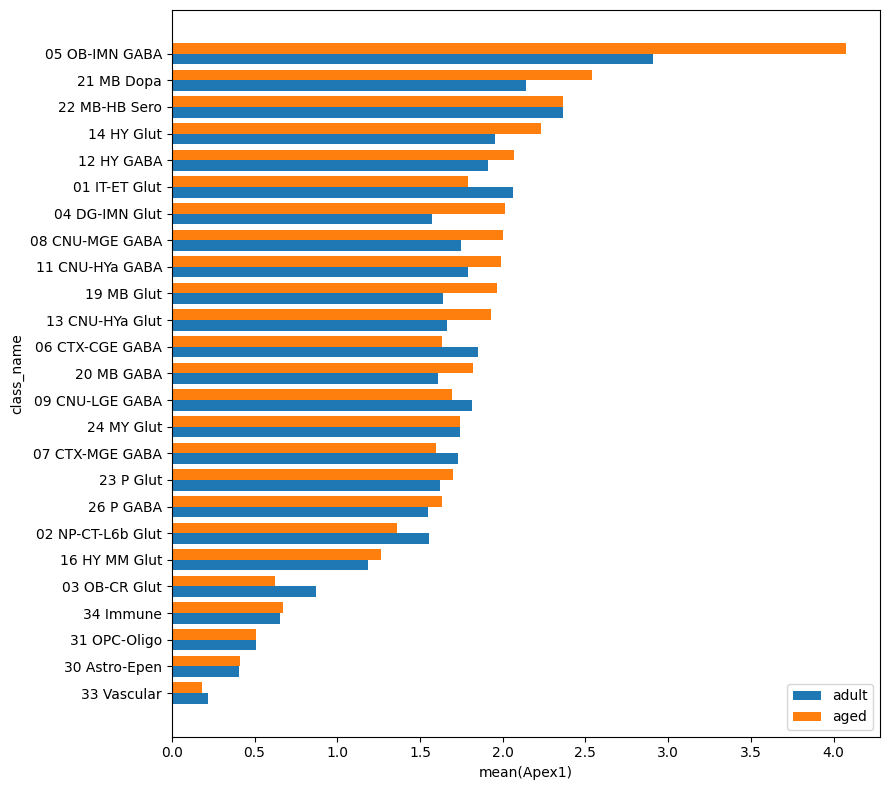

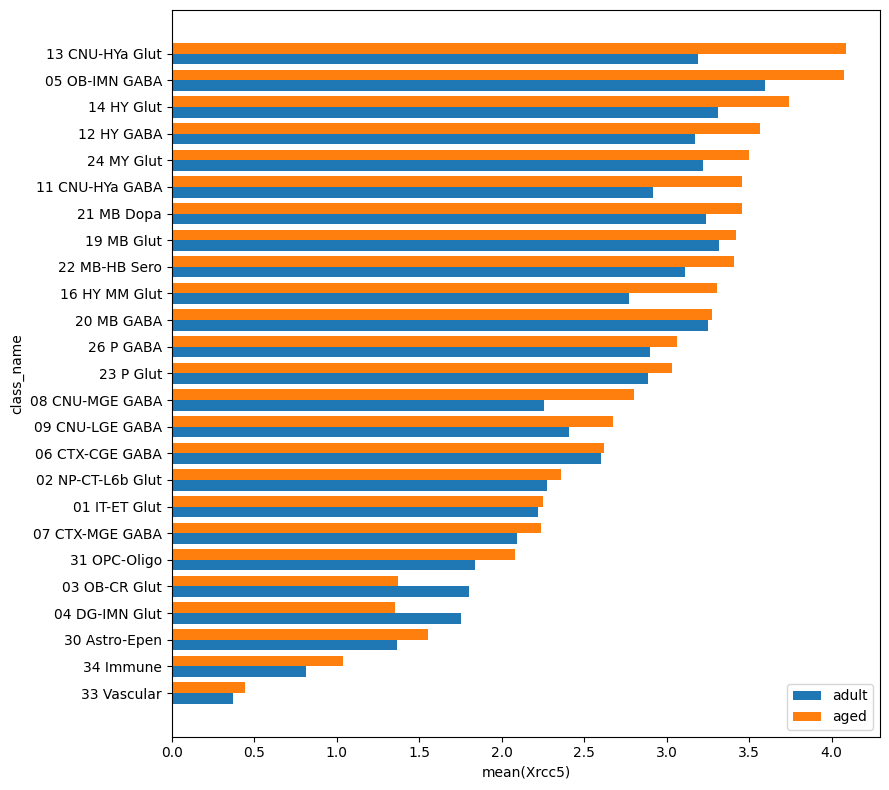

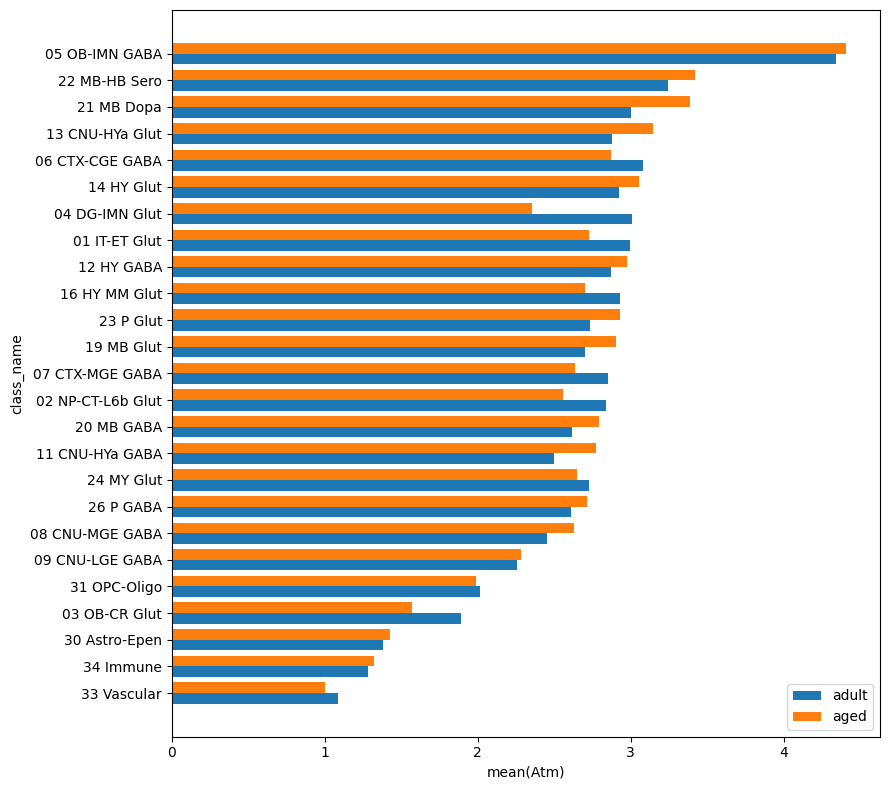

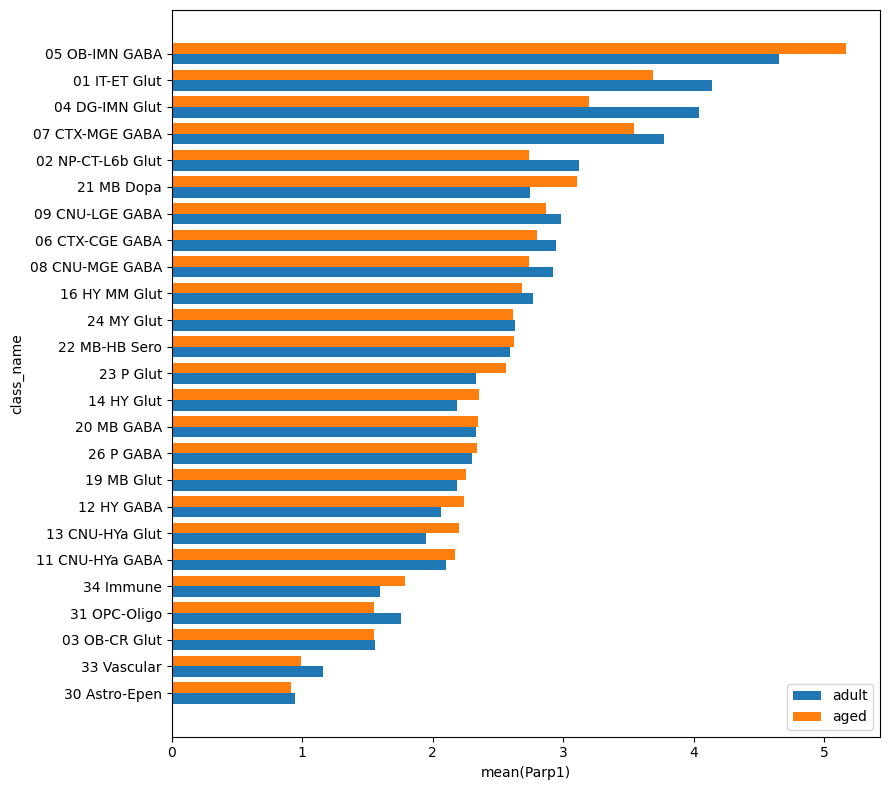

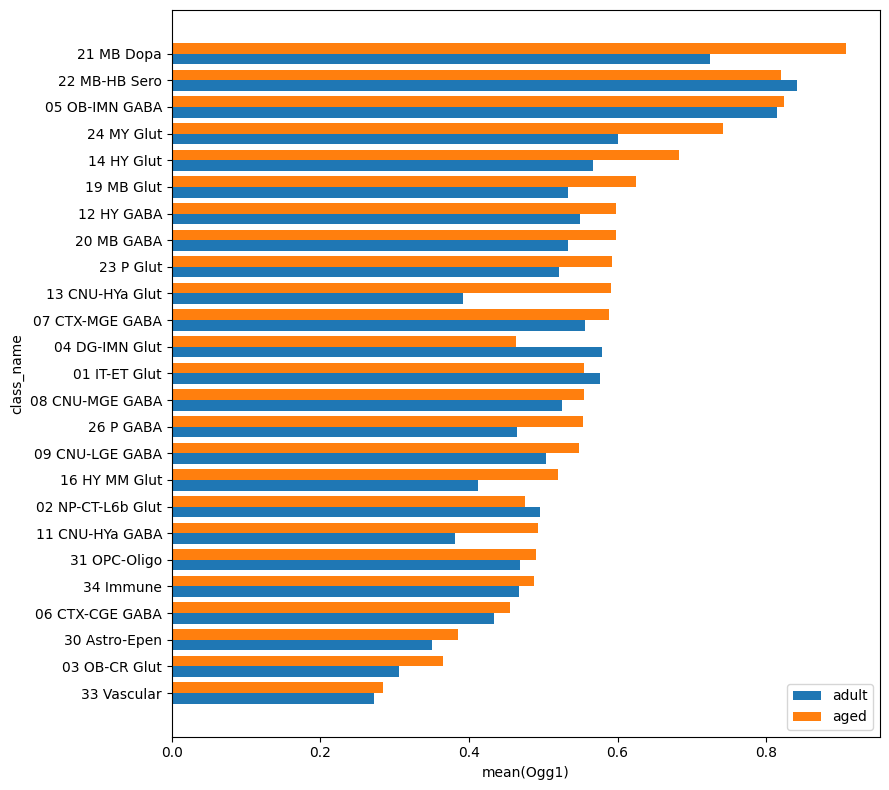

In [37]:
for g in gene_names:
    plot_gene_by_class(
        cell_extended_with_genes,
        g,
        group="class_name"
    )
# plot_gene_by_class(cell_extended_with_genes, "Apex1", group="neurotransmitter_label")

In [47]:
cell_extended_with_genes[cell_extended_with_genes["class_name"]=="01 IT-ET Glut"]["subclass_name"].value_counts()


subclass_name
016 CA1-ProS Glut            25349
006 L4/5 IT CTX Glut         24057
007 L2/3 IT CTX Glut         20141
005 L5 IT CTX Glut           16045
019 L2/3 IT PPP Glut         16025
020 L2/3 IT RSP Glut         13810
004 L6 IT CTX Glut           12955
022 L5 ET CTX Glut            5517
008 L2/3 IT ENT Glut          5110
009 L2/3 IT PIR-ENTl Glut     4421
023 SUB-ProS Glut             4060
002 IT EP-CLA Glut            3761
018 L2 IT PPP-APr Glut        3545
017 CA3 Glut                  2908
003 L5/6 IT TPE-ENT Glut      2485
021 L4 RSP-ACA Glut           1725
015 ENTmv-PA-COAp Glut        1493
011 L2 IT ENT-po Glut         1492
001 CLA-EPd-CTX Car3 Glut      851
024 L5 PPP Glut                427
025 CA2-FC-IG Glut             122
Name: count, dtype: int64

relevant columns:
- neurotransmitter_label
- region_of_interest_label
- anatomical_division_label
- donor_sex: 'M' or 'F'
- can use donor_age for plots but you would need to clean this up more use donor_age_category for now: 'aged' or 'adult'
- class_name, subclass_name

1. Overall mean gene expression differences between adult and aged cells
    * How do they classify a cell as aged - what is the cutoff, can you do a more granular analysis
2. Class specific gene expression differences between adult and aged cells
    * E.g. APE1 expression in IT-ET Glut in old vs young

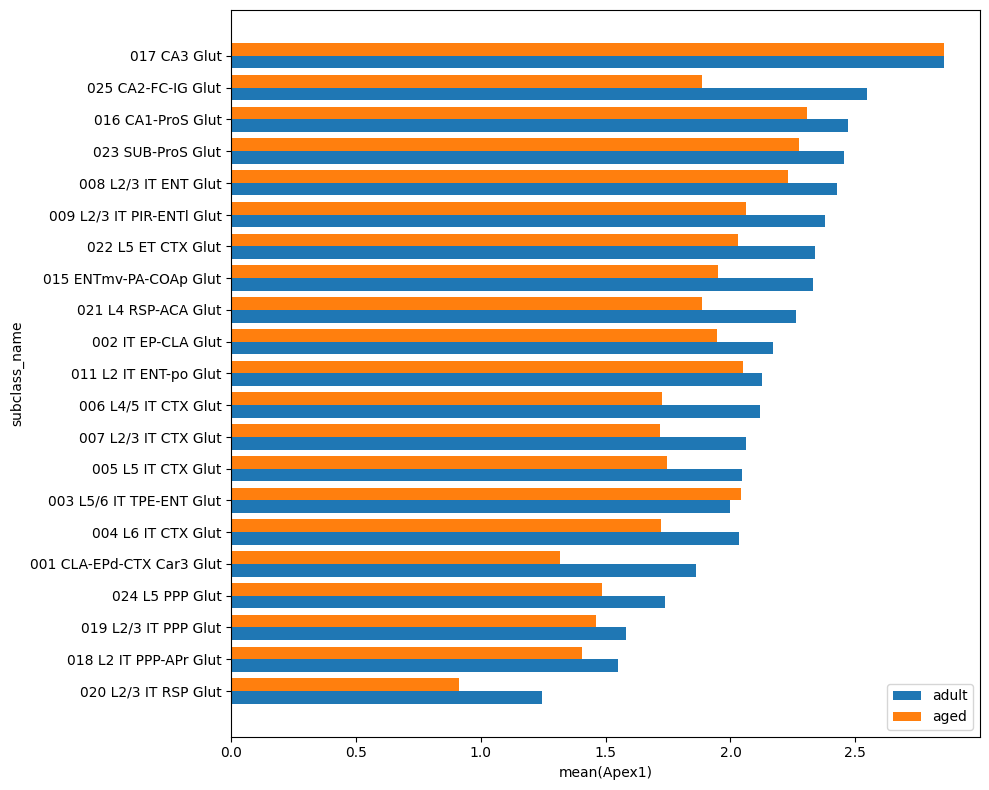

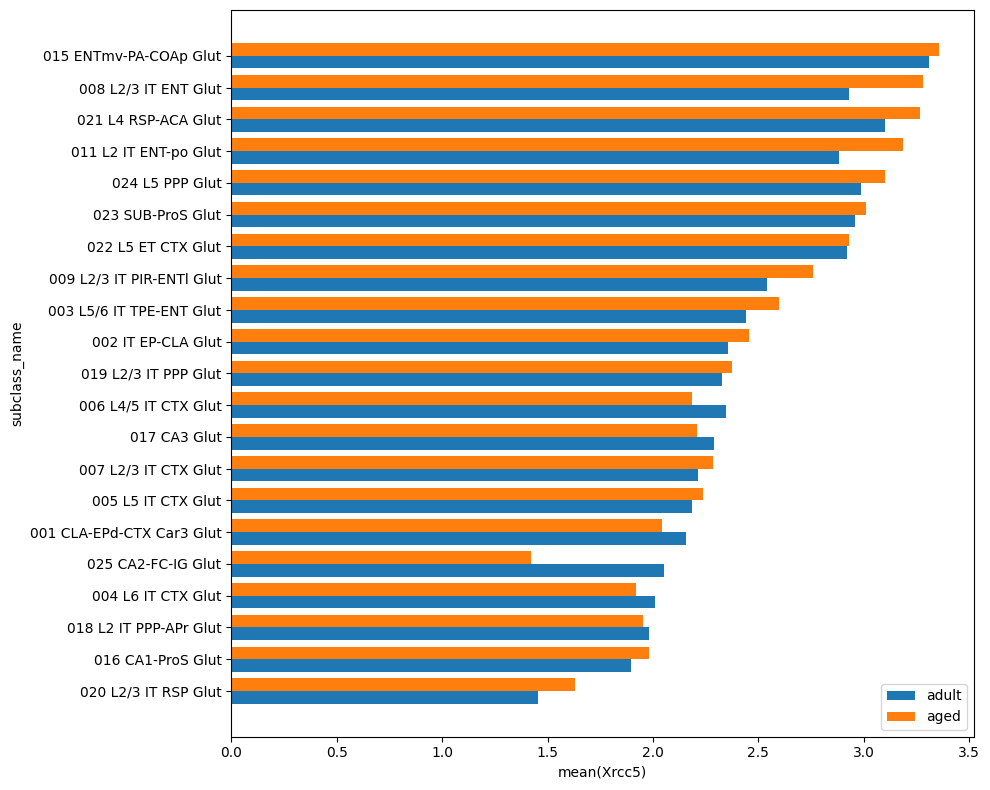

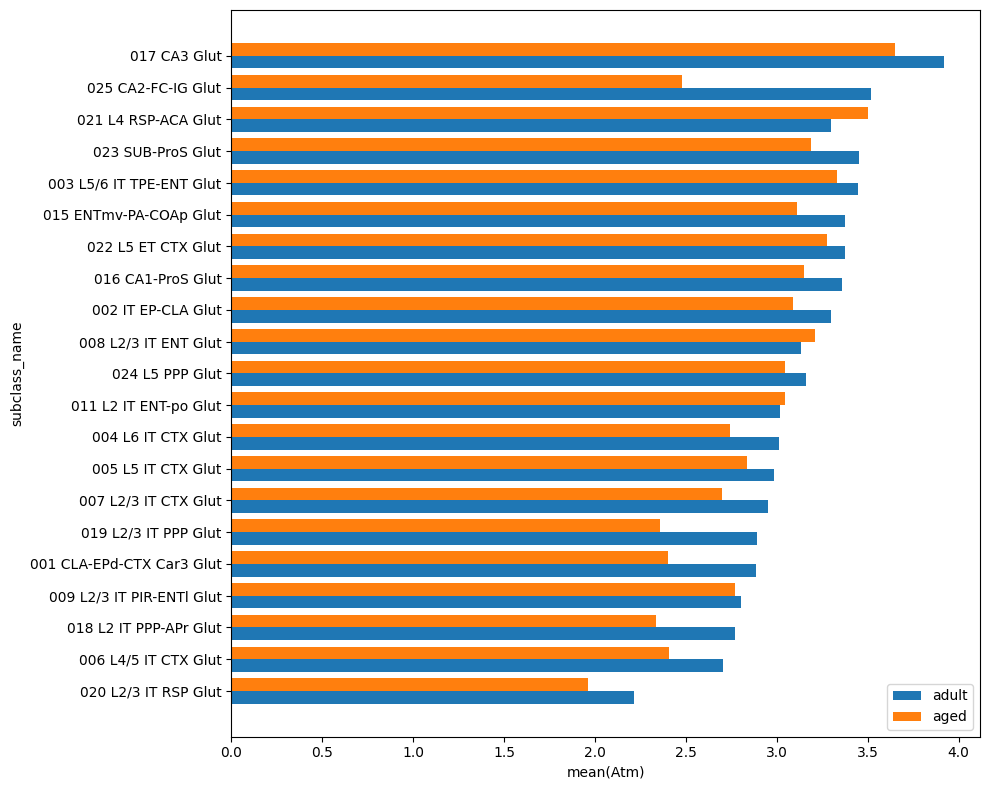

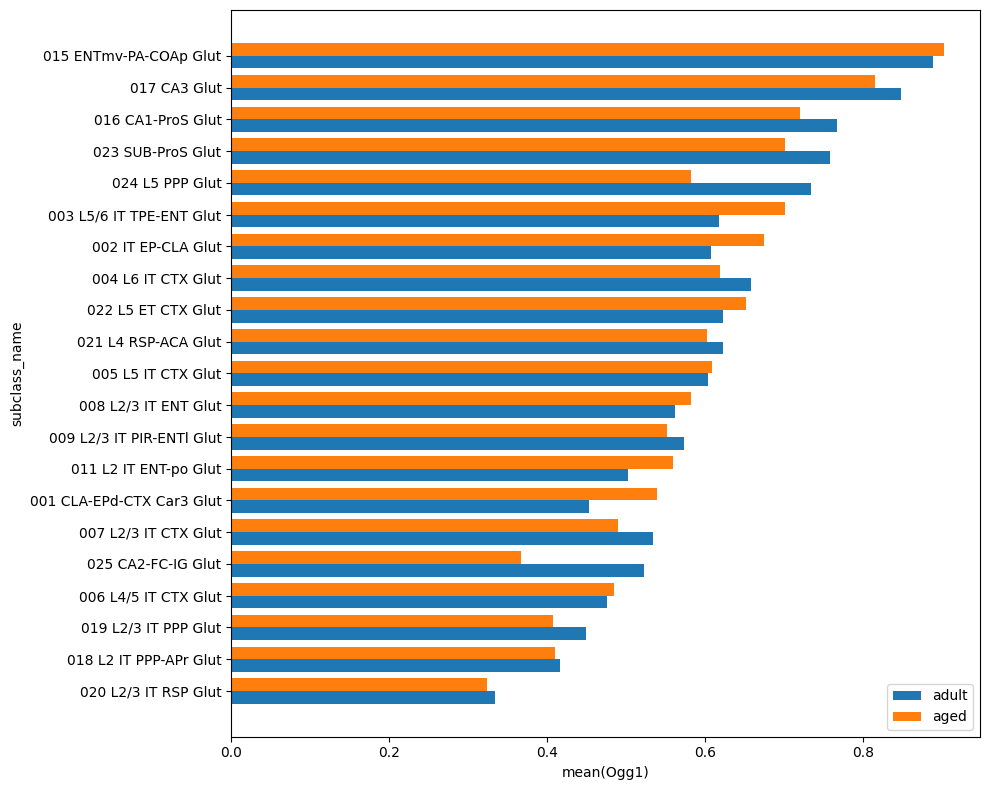

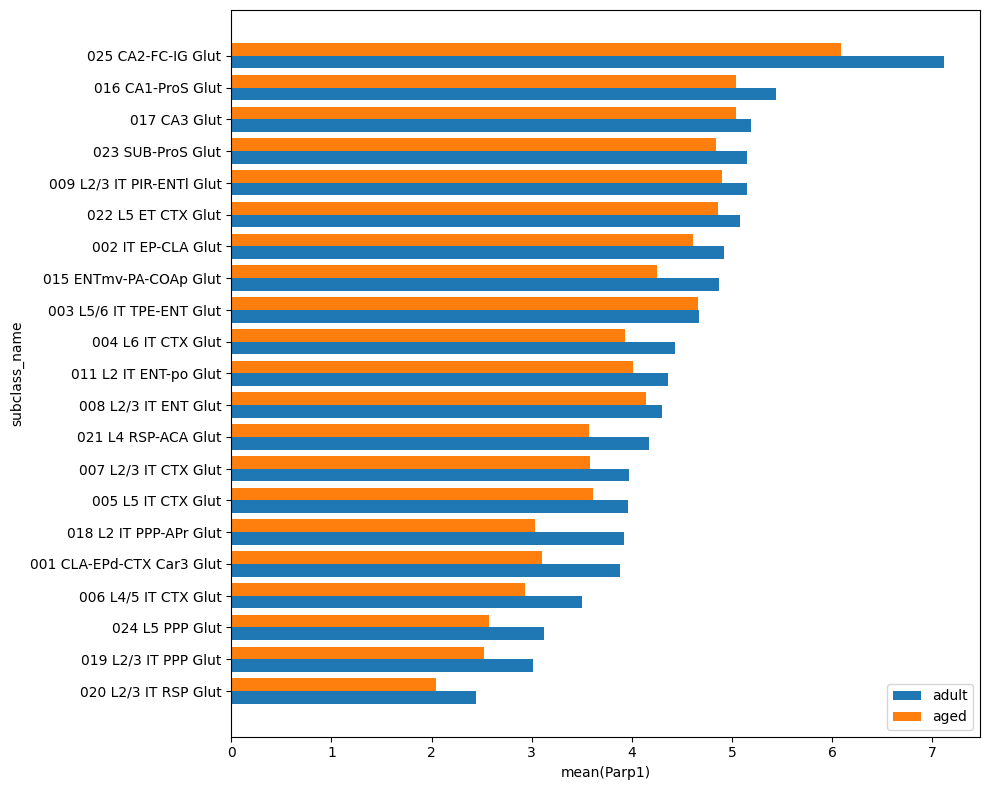

In [48]:
subclasses = [
    "016 CA1-ProS Glut",
    "006 L4/5 IT CTX Glut",
    "007 L2/3 IT CTX Glut",
    "005 L5 IT CTX Glut",
    "019 L2/3 IT PPP Glut",
    "020 L2/3 IT RSP Glut",
    "004 L6 IT CTX Glut",
    "022 L5 ET CTX Glut",
    "008 L2/3 IT ENT Glut",
    "009 L2/3 IT PIR-ENTl Glut",
    "023 SUB-ProS Glut",
    "002 IT EP-CLA Glut",
    "018 L2 IT PPP-APr Glut",
    "017 CA3 Glut",
    "003 L5/6 IT TPE-ENT Glut",
    "021 L4 RSP-ACA Glut",
    "015 ENTmv-PA-COAp Glut",
    "011 L2 IT ENT-po Glut",
    "001 CLA-EPd-CTX Car3 Glut",
    "024 L5 PPP Glut",
    "025 CA2-FC-IG Glut",
]

genes = ["Apex1", "Xrcc5", "Atm", "Ogg1", "Parp1"]  # or gene_names if you already have it

df_sub = cell_extended_with_genes[cell_extended_with_genes["subclass_name"].isin(subclasses)].copy()

for g in genes:
    plot_gene_by_class(
        df_sub,
        g,
        group="subclass_name",
        figsize=(10, 8)  # tweak as needed
    )


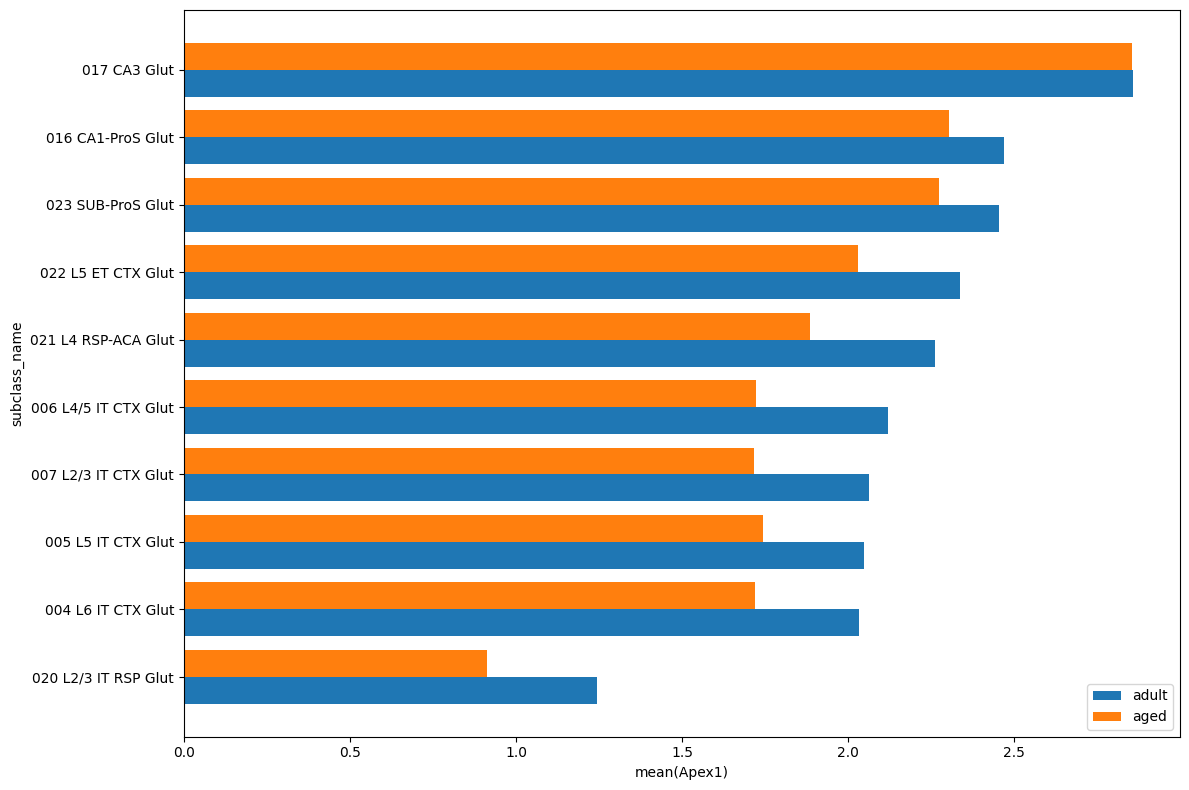

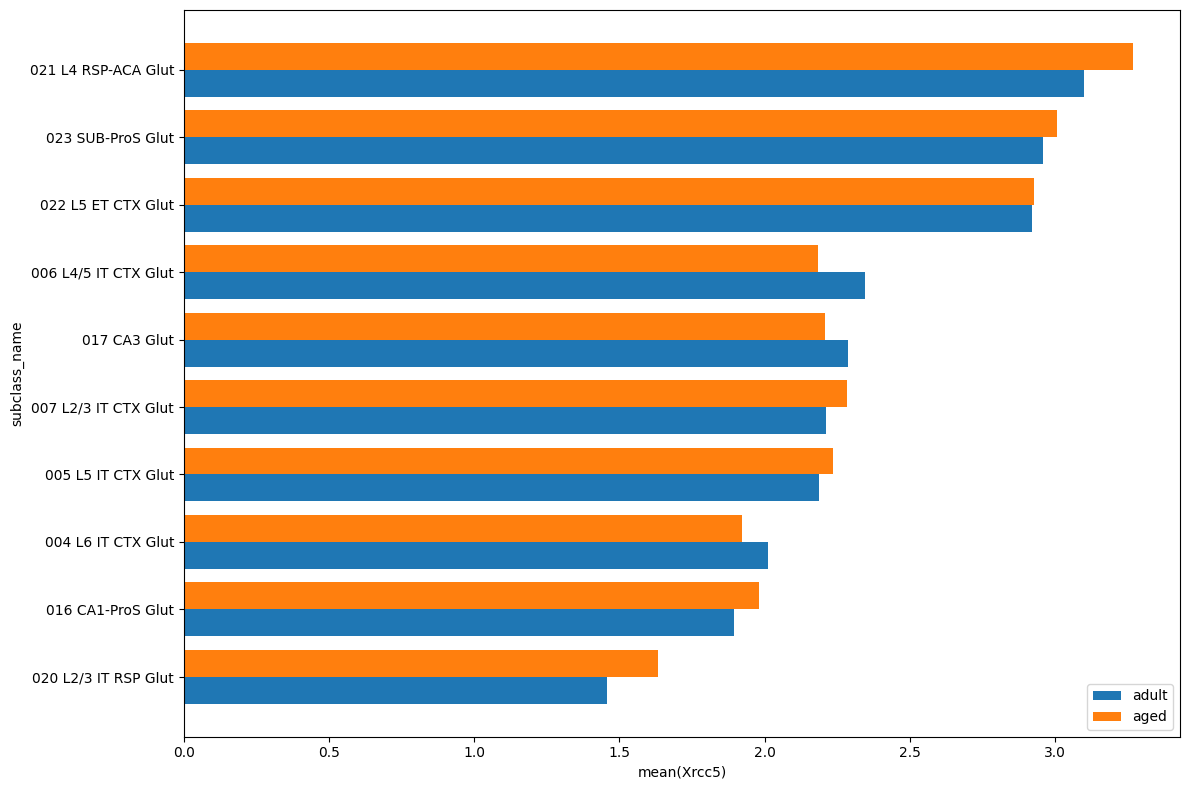

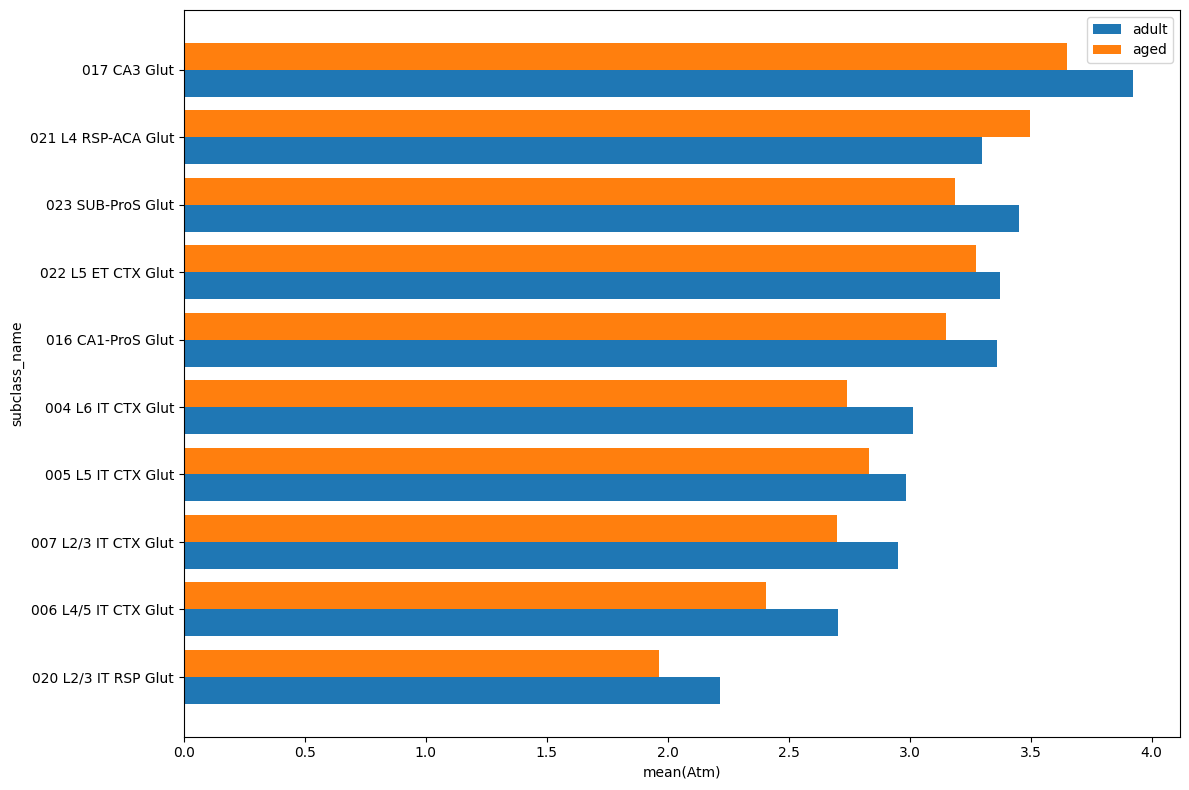

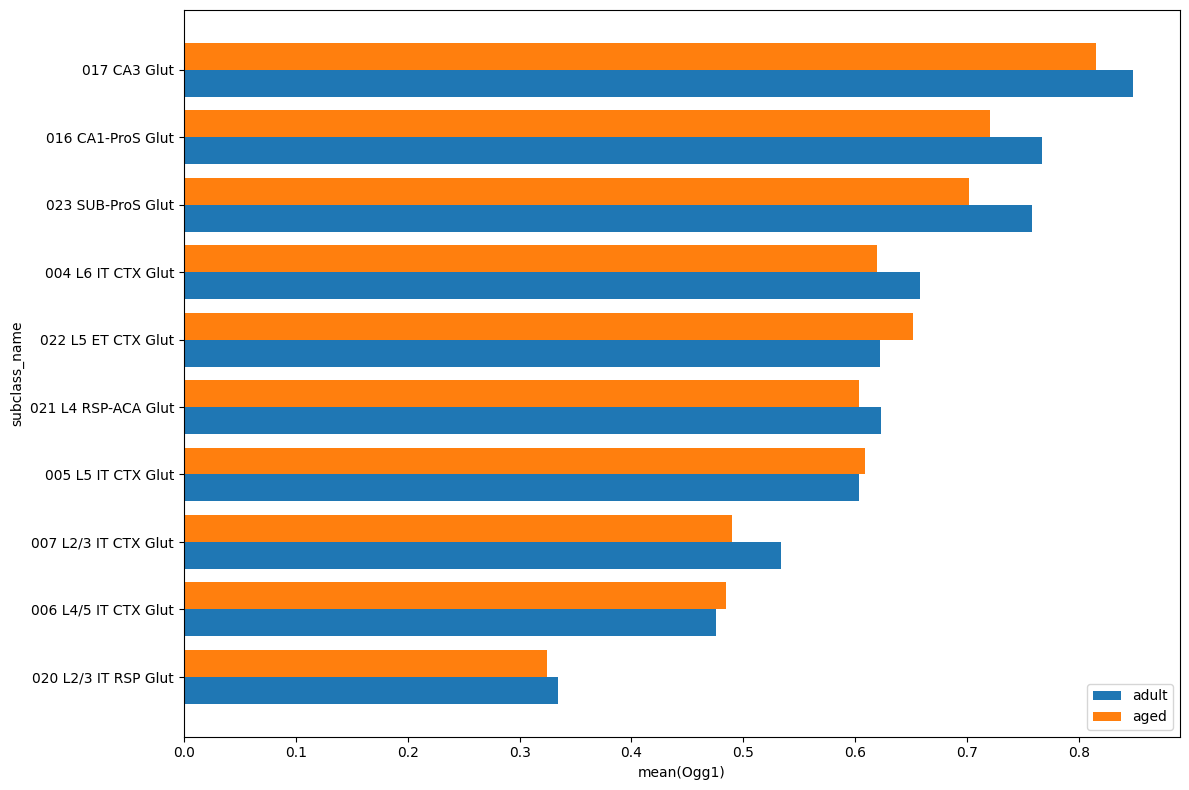

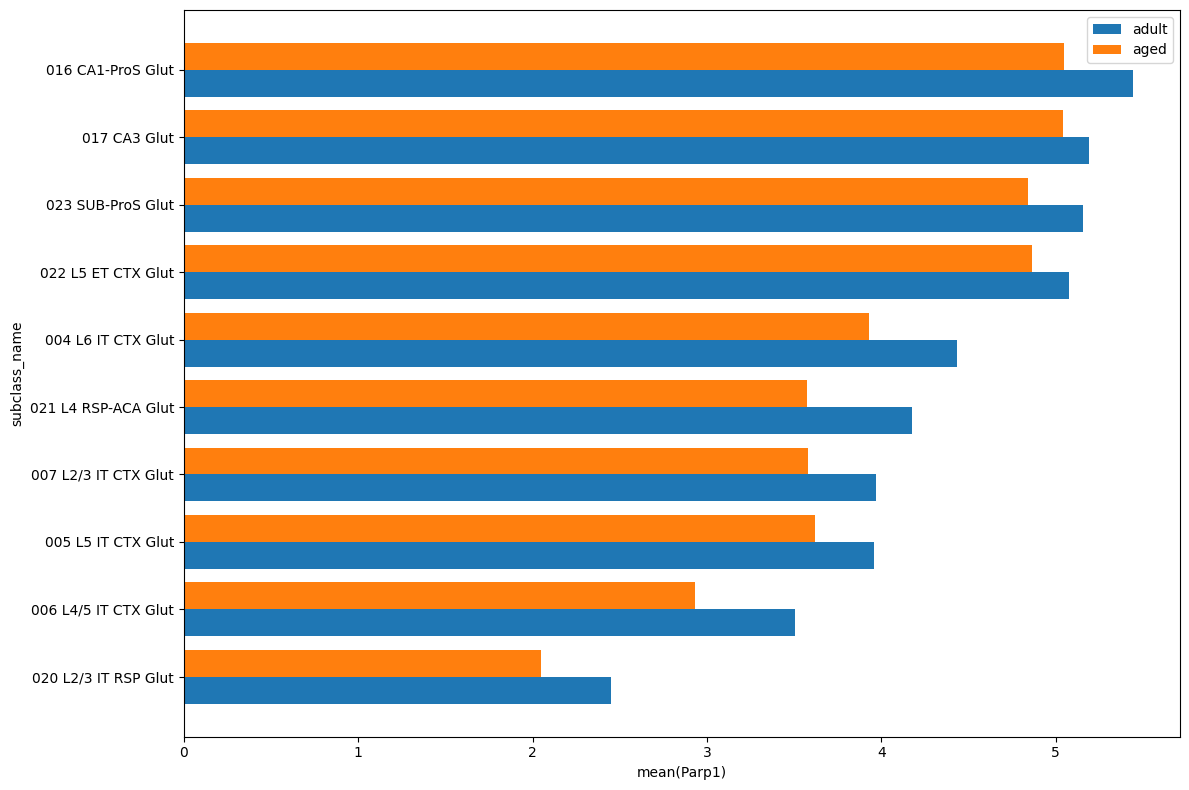

In [49]:
subclasses_keep = [
    "006 L4/5 IT CTX Glut",
    "007 L2/3 IT CTX Glut",
    "005 L5 IT CTX Glut",
    "004 L6 IT CTX Glut",
    "022 L5 ET CTX Glut",
    "016 CA1-ProS Glut",
    "017 CA3 Glut",
    "023 SUB-ProS Glut",
    "020 L2/3 IT RSP Glut",
    "021 L4 RSP-ACA Glut",
]

genes = ["Apex1", "Xrcc5", "Atm", "Ogg1", "Parp1"]

df_sub = cell_extended_with_genes[
    cell_extended_with_genes["subclass_name"].isin(subclasses_keep)
]

for g in genes:
    plot_gene_by_class(
        df_sub,
        g,
        group="subclass_name",
        figsize=(12, 8)
    )
